# L20+ SQL III

- Subqueries

- Window Functions

## 1 Subqueries `()`

- A **subquery** is a query nested inside another query

  - Remember, all queries return something (No matter **a single data point, a series or a rectangular table**)

  - You need to **be clear about what is returned exactly** for SQL to function properly

  - Use `()` to indicate subqueries

- The inner queries will be executed first, then the outer queries

## 2 Window Functions `OVER`

#### Initialization

In [ ]:
# ① Create DB + Initializa SQL
import sqlite3

conn = sqlite3.connect("window_functions.db")

with open("win_func_DDL.sql") as f:
    conn.executescript(f.read())

conn.close()

In [ ]:
# ② Linking Notebook to DB
%load_ext sql
%sql sqlite:///window_functions.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [6]:
%%sql
# Checking
SELECT *
FROM employee;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary
1,Adams,Andrew,Management,General Manager,2002-08-13,108000
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900
7,King,Robert,IT,IT Staff,2004-01-01,67800
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000
9,Edward,John,IT,IT Staff,2004-09-18,75900
10,Megan,Hanks,Sales,Sales Support Agent,2005-10-16,71500


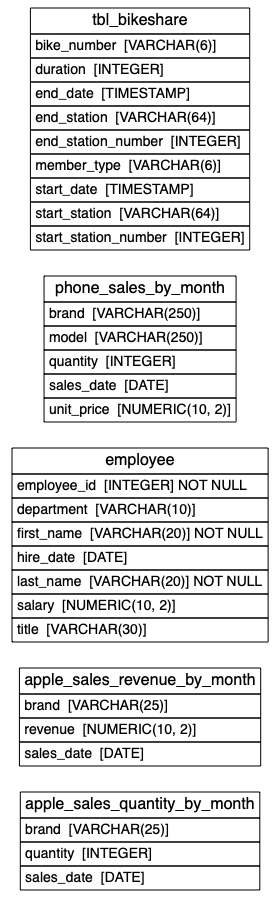

In [8]:
from eralchemy2 import render_er
from IPython.display import Image, display

# Get familiar with the db
render_er("sqlite:///window_functions.db", "schema_window_functions.png") 
display(Image("schema_window_functions.png")) 

### Motivation

- We already know how to use `GROUP BY` to do operations to a subset of rows

- But it is aggregated, sometimes we still want to **preserve the original row while comparing with groups**

#### The difference Between `GROUPBY` & Window functions

**`GROUPBY`**

- `GROUP BY` allows us to use aggregation functions

  - It **collapses all rows in the group into a single row**

**Window Functions**

- Window functions **don't collapse rows** even when applying aggregation functions

![alt text](https://s3.amazonaws.com/dq-content/772/1.1-m772.svg)

**e.g.**

- This is the orginal table `tbl_bikeshare`

In [10]:
%%sql
SELECT *
FROM tbl_bikeshare;

Running query in 'sqlite:///window_functions.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type
2017-10-01 01:00:00.000000,2017-10-01 01:04:00.000000,285,31400,Georgia & New Hampshire Ave NW,31404,9th & Upshur St NW,W22821,Member
2017-10-01 01:01:00.000000,2017-10-01 01:15:00.000000,816,31522,2nd St & Seaton Pl NE,31618,4th & East Capitol St NE,W00940,Member
2017-10-01 01:01:00.000000,2017-10-01 01:34:00.000000,2000,31044,King St & Patrick St,31041,Prince St & Union St,W00201,Casual
2017-10-01 01:02:00.000000,2017-10-01 01:15:00.000000,798,31288,4th St & Madison Dr NW,31266,11th & M St NW,W23360,Member
2017-10-01 01:02:00.000000,2017-10-01 02:09:00.000000,3978,31258,Lincoln Memorial,31233,17th & K St NW / Farragut Square,W22595,Casual
2017-10-01 01:03:00.000000,2017-10-01 01:25:00.000000,1325,31230,Metro Center / 12th & G St NW,31613,Eastern Market Metro / Pennsylvania Ave & 7th St SE,W20671,Member
2017-10-01 01:03:00.000000,2017-10-01 01:41:00.000000,2259,31272,Washington & Independence Ave SW/HHS,31272,Washington & Independence Ave SW/HHS,W20604,Casual
2017-10-01 01:03:00.000000,2017-10-01 01:10:00.000000,433,31278,18th & R St NW,31109,7th & T St NW,W22038,Casual
2017-10-01 01:04:00.000000,2017-10-01 01:15:00.000000,671,31258,Lincoln Memorial,31277,17th & G St NW,W21107,Member
2017-10-01 01:04:00.000000,2017-10-01 01:10:00.000000,323,31281,8th & O St NW,31251,12th & L St NW,W22410,Member


- When we group them by `member_type` and compute the avg `duration`

In [ ]:
%%sql
SELECT member_type, AVG(duration) AS avg_trip_duration
FROM tbl_bikeshare
GROUP BY member_type;

Running query in 'sqlite:///window_functions.db'

member_type,avg_trip_duration
Casual,2223.74358974359
Member,733.0706225680934


- Let's see a window function first (will learn how to code it later)

In [11]:
%%sql
SELECT bike_number, member_type, duration,
       AVG(duration) OVER(PARTITION BY member_type) AS avg_trip_duration
  FROM tbl_bikeshare;

Running query in 'sqlite:///window_functions.db'

bike_number,member_type,duration,avg_trip_duration
W00201,Casual,2000,2223.74358974359
W22595,Casual,3978,2223.74358974359
W20604,Casual,2259,2223.74358974359
W22038,Casual,433,2223.74358974359
W00035,Casual,1890,2223.74358974359
W00520,Casual,1788,2223.74358974359
W23129,Casual,1511,2223.74358974359
W23375,Casual,1028,2223.74358974359
W22633,Casual,1737,2223.74358974359
W20504,Casual,2321,2223.74358974359


- We still preserve the original rows while appending a new col of aggregated data (`AVG`)

- `AVG` here represents the **window function** for window `OVER(PARTITION BY member_type)`

### `OVER`

- Let's see one example of window function

- First we check the table we are gonna deal with

In [12]:
%%sql
SELECT * 
  FROM employee;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary
1,Adams,Andrew,Management,General Manager,2002-08-13,108000
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900
7,King,Robert,IT,IT Staff,2004-01-01,67800
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000
9,Edward,John,IT,IT Staff,2004-09-18,75900
10,Megan,Hanks,Sales,Sales Support Agent,2005-10-16,71500


- Say we want to prepare info of employees and add one more col behind to show the **average salary of them all**

In [ ]:
%%sql
SELECT first_name, last_name, department, title, salary,
       (AVG(salary) OVER()) AS average_salary
  FROM employee;

Running query in 'sqlite:///window_functions.db'

first_name,last_name,department,title,salary,average_salary
Andrew,Adams,Management,General Manager,108000,82330.0
Nancy,Edwards,Sales,Sales Manager,98900,82330.0
Jane,Peacock,Sales,Sales Support Agent,87000,82330.0
Margaret,Park,Sales,Sales Support Agent,69800,82330.0
Steve,Johnson,Sales,Sales Support Agent,76500,82330.0
Michael,Mitchell,IT,IT Manager,89900,82330.0
Robert,King,IT,IT Staff,67800,82330.0
Laura,Callahan,IT,IT Staff,78000,82330.0
John,Edward,IT,IT Staff,75900,82330.0
Hanks,Megan,Sales,Sales Support Agent,71500,82330.0


- `OVER()` clause defines the **window**: which rows are included in a window

  - In this case, the window is the entire rows

- So the **window function `AVG` is computed over the window** "the whole rows"

- `AVG(salary) OVER()` is a chunk and you can also ignore the outer `()`

### `PARTITION BY` Different Windows

- What if we don't want to compute over the whole dataset?

- We change the window by using `PARTITION BY` in the `OVER()`

In [14]:
%%sql
SELECT first_name, last_name, department, title, salary,
       AVG(salary) OVER(PARTITION BY department) AS average_salary
  FROM employee;

Running query in 'sqlite:///window_functions.db'

first_name,last_name,department,title,salary,average_salary
Michael,Mitchell,IT,IT Manager,89900,77900.0
Robert,King,IT,IT Staff,67800,77900.0
Laura,Callahan,IT,IT Staff,78000,77900.0
John,Edward,IT,IT Staff,75900,77900.0
Andrew,Adams,Management,General Manager,108000,108000.0
Nancy,Edwards,Sales,Sales Manager,98900,80740.0
Jane,Peacock,Sales,Sales Support Agent,87000,80740.0
Margaret,Park,Sales,Sales Support Agent,69800,80740.0
Steve,Johnson,Sales,Sales Support Agent,76500,80740.0
Hanks,Megan,Sales,Sales Support Agent,71500,80740.0


- By using `PARTITION BY`, we separate several parts (windows) to perform the window function on

  - Here we first separate by department and then compute the average within that department

![alt text](https://s3.amazonaws.com/dq-content/772/5.2-m772.svg)

### `ORDER BY` Cumulative Computation

- Sometimes we may want to see the cumulative result like running total sales through the whole year

  - First we need to order the data in the right way
  
  - Then perform the computation one by one

**e.g.**

- Say we want to get the running total of monthly sales for Apple

In [16]:
%%sql
SELECT sales_date, brand, quantity, (SUM(quantity) OVER(ORDER BY sales_date)) AS running_total_quantity
FROM apple_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity,running_total_quantity
2022-01-31,Apple,50,50
2022-02-28,Apple,40,90
2022-03-31,Apple,25,115
2022-04-30,Apple,30,145
2022-05-31,Apple,47,192
2022-06-30,Apple,40,232


- `OVER(ORDER BY sales_date)` re-arranges the `sale_date` in ascending order

- Then performs `SUM(quantity)` from top to bottom

### `ROWS` Window Framing

- With `ORDER BY` we can compute cumulative things, but it always starts from the first row

- What if we just want 5 rows previous to or after current row? (The window itself is moving)

- Say we want to compute the **average of 3 rows: previous 1 row, current row, and 1 row after**

In [18]:
%%sql
SELECT *,
       AVG(quantity) OVER(ROWS BETWEEN 1 PRECEDING AND 1 FOLLOWING) AS avg_quantity
  FROM apple_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity,avg_quantity
2022-01-31,Apple,50,45.0
2022-02-28,Apple,40,38.333333333333336
2022-03-31,Apple,25,31.666666666666668
2022-04-30,Apple,30,34.0
2022-05-31,Apple,47,39.0
2022-06-30,Apple,40,43.5


- For the first row since there is not previous row, SQL will **just use current and following rows and divided by 2**

  - The last element follows the same logic
  
  - When using `PARTITION BY`, each partition follows the same logic

**e.g.**

- Let's create one more table and insert some data

In [25]:
%%sql

CREATE TABLE phone_sales_revenue_by_month
(
    sales_date DATE,
    brand      VARCHAR(250),
    revenue    NUMERIC(10, 2)
);

Running query in 'sqlite:///window_functions.db'

++
||
++
++

In [28]:
%%sql
insert into phone_sales_revenue_by_month (sales_date, brand, revenue)
values  ('2022-01-31', 'Apple', 49950.00),
        ('2022-02-28', 'Apple', 36960.00),
        ('2022-03-31', 'Apple', 24975.00),
        ('2022-04-30', 'Apple', 17970.00),
        ('2022-05-31', 'Apple', 28753.00),
        ('2022-06-30', 'Apple', 23960.00),
        ('2022-01-31', 'Samsung', 48921.00),
        ('2022-02-28', 'Samsung', 43200.00),
        ('2022-03-31', 'Samsung', 25790.00),
        ('2022-04-30', 'Samsung', 31240.00),
        ('2022-05-31', 'Samsung', 70295.00),
        ('2022-06-30', 'Samsung', 59821.00);;

Running query in 'sqlite:///window_functions.db'

12 rows affected.

++
||
++
++

In [29]:
%%sql

SELECT * FROM phone_sales_revenue_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,revenue
2022-01-31,Apple,49950
2022-02-28,Apple,36960
2022-03-31,Apple,24975
2022-04-30,Apple,17970
2022-05-31,Apple,28753
2022-06-30,Apple,23960
2022-01-31,Samsung,48921
2022-02-28,Samsung,43200
2022-03-31,Samsung,25790
2022-04-30,Samsung,31240


In [ ]:
%%sql
SELECT *,
       AVG(revenue) OVER(PARTITION BY brand
                         ORDER BY sales_date
                         ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS average_revenue
  FROM phone_sales_revenue_by_month;

![alt text](https://s3.amazonaws.com/dq-content/773/5.3-m773_v2.gif)

- You can also exclude the current row by using 2 `PRECEDING` / `FOLLOWING`

In [31]:
%%sql
SELECT *,
       AVG(revenue) OVER(PARTITION BY brand
                         ORDER BY sales_date
                         ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING) AS avg_previous_revenues
  FROM phone_sales_revenue_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,revenue,avg_previous_revenues
2022-01-31,Apple,49950,None
2022-02-28,Apple,36960,49950.0
2022-03-31,Apple,24975,43455.0
2022-04-30,Apple,17970,37295.0
2022-05-31,Apple,28753,32463.75
2022-06-30,Apple,23960,31721.6
2022-01-31,Samsung,48921,None
2022-02-28,Samsung,43200,48921.0
2022-03-31,Samsung,25790,46060.5
2022-04-30,Samsung,31240,39303.666666666664


- In this case, there could be some `NONE`

- You can appoint $N$ preceding rows and $M$ following rows

- You can use 2 `PRECEDING` or 2 `FOLLOWING`

![alt text](https://s3.amazonaws.com/dq-content/773/2.1-m773.svg)

- You can also use this method to minic cumulative computation using `ORDER BY`

In [21]:
%%sql
SELECT sales_date, brand, quantity, (SUM(quantity) OVER(ORDER BY sales_date)) AS running_total_quantity
FROM apple_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity,running_total_quantity
2022-01-31,Apple,50,50
2022-02-28,Apple,40,90
2022-03-31,Apple,25,115
2022-04-30,Apple,30,145
2022-05-31,Apple,47,192
2022-06-30,Apple,40,232


In [20]:
%%sql
SELECT *,
       SUM(quantity) OVER(ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS avg_quantity
  FROM apple_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity,avg_quantity
2022-01-31,Apple,50,50
2022-02-28,Apple,40,90
2022-03-31,Apple,25,115
2022-04-30,Apple,30,145
2022-05-31,Apple,47,192
2022-06-30,Apple,40,232


<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Summary**

`ROWS BETWEEN` ... `AND` ...

- `CURRENT ROW`

- `N PRECEDING` / `UNBOUNDED PRECEDING`

- `M FOLLOWING` / `UNBOUNDED FOLLOWING`

</div>


In [ ]:
--- Summary ---

function_name([expression]) OVER 
(
    [partition_definition]
    [order_definition]
    [frame_definition]
) [AS column_name] 

### `RANGE` & `ROWS`

- Except for `ROWS`, we may achieve similar results by using `RANGE`

In [33]:
%%sql
create table samsung_sales_quantity
(
    sales_date date,
    brand      varchar(20),
    model      varchar(40),
    quantity   integer
);

insert into samsung_sales_quantity (sales_date, brand, model, quantity)
values  ('2022-01-31', 'Samsung', 'Samsung Galaxy S22 Ultra', 30),
        ('2022-01-31', 'Samsung', 'Samsung Galaxy Z Fold4', 40),
        ('2022-02-28', 'Samsung', 'Samsung Galaxy S22 Ultra', 35),
        ('2022-03-31', 'Samsung', 'Samsung Galaxy Z Fold4', 60),
        ('2022-03-31', 'Samsung', 'Samsung Galaxy S22 Ultra', 25),
        ('2022-04-30', 'Samsung', 'Samsung Galaxy Z Fold4', 25),
        ('2022-05-31', 'Samsung', 'Samsung Galaxy Z Fold4', 30),
        ('2022-06-30', 'Samsung', 'Samsung Galaxy Z Fold4', 76),
        ('2022-05-31', 'Samsung', 'Samsung Galaxy S22 Ultra', 47);

Running query in 'sqlite:///window_functions.db'

9 rows affected.

++
||
++
++

In [35]:
%%sql

SELECT * FROM samsung_sales_quantity;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,model,quantity
2022-01-31,Samsung,Samsung Galaxy S22 Ultra,30
2022-01-31,Samsung,Samsung Galaxy Z Fold4,40
2022-02-28,Samsung,Samsung Galaxy S22 Ultra,35
2022-03-31,Samsung,Samsung Galaxy Z Fold4,60
2022-03-31,Samsung,Samsung Galaxy S22 Ultra,25
2022-04-30,Samsung,Samsung Galaxy Z Fold4,25
2022-05-31,Samsung,Samsung Galaxy Z Fold4,30
2022-06-30,Samsung,Samsung Galaxy Z Fold4,76
2022-05-31,Samsung,Samsung Galaxy S22 Ultra,47


In [34]:
%%sql
SELECT *,
       SUM(quantity) OVER(
                            ORDER BY sales_date
                            ROWS UNBOUNDED PRECEDING
                          ) AS cumulative_quantity_with_rows
  FROM samsung_sales_quantity;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,model,quantity,cumulative_quantity_with_rows
2022-01-31,Samsung,Samsung Galaxy S22 Ultra,30,30
2022-01-31,Samsung,Samsung Galaxy Z Fold4,40,70
2022-02-28,Samsung,Samsung Galaxy S22 Ultra,35,105
2022-03-31,Samsung,Samsung Galaxy Z Fold4,60,165
2022-03-31,Samsung,Samsung Galaxy S22 Ultra,25,190
2022-04-30,Samsung,Samsung Galaxy Z Fold4,25,215
2022-05-31,Samsung,Samsung Galaxy Z Fold4,30,245
2022-05-31,Samsung,Samsung Galaxy S22 Ultra,47,292
2022-06-30,Samsung,Samsung Galaxy Z Fold4,76,368


- Instead of monitoring the changes in running total quantities of sold phones during a single month, i.e. different value while progressing (**Row-targeted**)

- What if we want to know the running total quantities of all sales in a single month, i.e. **same value for the same month**? (**Value-targeted**)

- We can see that within the same month, the `cumulative_quantity_with_range` is the same

In [37]:
%%sql
SELECT *,
SUM(quantity) OVER(ORDER BY sales_date
                   RANGE BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING) AS rev_run_quantity
FROM samsung_sales_quantity;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,model,quantity,rev_run_quantity
2022-01-31,Samsung,Samsung Galaxy S22 Ultra,30,368
2022-01-31,Samsung,Samsung Galaxy Z Fold4,40,368
2022-02-28,Samsung,Samsung Galaxy S22 Ultra,35,298
2022-03-31,Samsung,Samsung Galaxy Z Fold4,60,263
2022-03-31,Samsung,Samsung Galaxy S22 Ultra,25,263
2022-04-30,Samsung,Samsung Galaxy Z Fold4,25,178
2022-05-31,Samsung,Samsung Galaxy Z Fold4,30,153
2022-05-31,Samsung,Samsung Galaxy S22 Ultra,47,153
2022-06-30,Samsung,Samsung Galaxy Z Fold4,76,76


- We also have short-form codes, but we recommend you to write it clearly

In [ ]:
%%sql

SELECT *,
       SUM(quantity) OVER(
                            ORDER BY sales_date
                            RANGE UNBOUNDED PRECEDING
                          ) AS cumulative_quantity_with_range
  FROM samsung_sales_quantity;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,model,quantity,cumulative_quantity_with_range
2022-01-31,Samsung,Samsung Galaxy S22 Ultra,30,70
2022-01-31,Samsung,Samsung Galaxy Z Fold4,40,70
2022-02-28,Samsung,Samsung Galaxy S22 Ultra,35,105
2022-03-31,Samsung,Samsung Galaxy Z Fold4,60,190
2022-03-31,Samsung,Samsung Galaxy S22 Ultra,25,190
2022-04-30,Samsung,Samsung Galaxy Z Fold4,25,215
2022-05-31,Samsung,Samsung Galaxy Z Fold4,30,292
2022-05-31,Samsung,Samsung Galaxy S22 Ultra,47,292
2022-06-30,Samsung,Samsung Galaxy Z Fold4,76,368


- `RANGE UNBOUNDED PRECEDING` is the same as `RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW`

- **BUT!** `RANGE UNBOUNDED PRECEDING` doesn't exist so just don't write this

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Summary**

`RANGE BETWEEN` ... `AND` ...

- `CURRENT ROW`

- `UNBOUNDED PRECEDING`

- `UNBOUNDED FOLLOWING`

</div>

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

- The `RANGE` operator **doesn't support** `n PRECEDING` and `n FOLLOWING` since it is not easy to recognize $n$ numbers preceding or following a specific value for a DBMS

</div>

- But what if you want to specify a time interval?

- We can use `INTERVAL` if it is a time problem

In [40]:
%%sql

SELECT *,
AVG(quantity) OVER(
                    ORDER BY sales_date
                    RANGE BETWEEN INTERVAL '2 months' PRECEDING AND CURRENT ROW) AS three_month_average

FROM samsung_sales_quantity;

Running query in 'sqlite:///window_functions.db'

RuntimeError: If using snippets, you may pass the --with argument explicitly.
For more details please refer: https://jupysql.ploomber.io/en/latest/compose.html#with-argument


Original error message from DB driver:
(sqlite3.OperationalError) near "'2 months'": syntax error
[SQL: SELECT *,
AVG(quantity) OVER(
                    ORDER BY sales_date
                    RANGE BETWEEN INTERVAL '2 months' PRECEDING AND CURRENT ROW) AS three_month_average

FROM samsung_sales_quantity;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)



- However, SQLite doesn't support this grammar

- We resolve it by using correlated subquery in SQLite

- But it is complex so not recommended to use SQLite. Use DuckDB!

In [43]:
%%sql
SELECT
    s1.*,

    (
        SELECT AVG(s2.quantity)
        FROM samsung_sales_quantity AS s2
        WHERE s2.sales_date
              BETWEEN DATE(s1.sales_date, '-2 months')
                  AND s1.sales_date
    ) AS three_month_average

FROM samsung_sales_quantity AS s1;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,model,quantity,three_month_average
2022-01-31,Samsung,Samsung Galaxy S22 Ultra,30,35.0
2022-01-31,Samsung,Samsung Galaxy Z Fold4,40,35.0
2022-02-28,Samsung,Samsung Galaxy S22 Ultra,35,35.0
2022-03-31,Samsung,Samsung Galaxy Z Fold4,60,38.0
2022-03-31,Samsung,Samsung Galaxy S22 Ultra,25,38.0
2022-04-30,Samsung,Samsung Galaxy Z Fold4,25,36.666666666666664
2022-05-31,Samsung,Samsung Galaxy Z Fold4,30,37.4
2022-06-30,Samsung,Samsung Galaxy Z Fold4,76,44.5
2022-05-31,Samsung,Samsung Galaxy S22 Ultra,47,37.4


- For subquery
  
  - We first get s1 (Start with each row one by one under the hood)

  - Then we can use s1.sales_date (actually the specific row) to determine the time interval to filter the rows in s2

  - Then for each row in s1, we can compute the average of rows that fulfill the requirements in s2

  - Then move on to the next row in s1, looping...

- All these codes can be combined together

In [ ]:
aggregate_function(column_name) OVER(
        [PARTITION BY clause]
        [ORDER BY clause]
        [window framing clause]
        )

- There are mainly **4 types of window functions**

  - Aggregation
  
  - Ranking
  
  - Distribution
  
  - Offset

- Now let's take a look at 4 different window functions separately

### **Aggregate** Functions

- This can be familiar since they are covered before

| Window Aggregate Function | Definition |
| --- | --- |
| `SUM(<i>expression</i>)` | Returns the sum of the rows from expression as viewed by the OVER clause. |
| `AVG(<i>expression</i>)<code>` | Returns the average of expression as viewed by the OVER clause. |
| `MIN(<i>expression</i>)<code>` | Finds the minimum value in a column given by expression as viewed by the OVER clause. |
| `MAX(<i>expression</i>)<code>` | Returns the highest value in a column given by expression as viewed by the OVER clause. |
| `COUNT(<i>expression</i>)<code>` | Returns a count of the number of non-NULL values of the expression as viewed by the OVER clause. |
| `VARIANCE(<i>expression</i>)<code>` | Returns the variance of all expression values as viewed by the OVER clause. |
| `STDDEV(<i>expression</i>)<code>` | Returns a sample standard deviation of all expression values as viewed by the OVER clause. |

- We may want to put window func into conditions

- **But we cannot put window functions in a `WHERE` clause**

In [ ]:
SELECT first_name, last_name, department, salary,
       AVG(salary) OVER() as average_salary
  FROM employees
 WHERE salary > AVG(salary) OVER(); -- This is the error line

- It will yield error

In [ ]:
ERROR: window functions are not allowed in WHERE

- We can use subquery to solve this issue

In [ ]:
SELECT f.first_name, f.last_name, f.salary
  FROM

       (SELECT e.first_name, e.last_name, e.salary,
	           AVG(e.salary) OVER() AS average_salary
          FROM employees AS e) AS f

 WHERE f.salary > f.average_salary;

-- Remember the inner temporary table must have a alias for outer query to refer, or it will error

- Why so?

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Order of Execution**

**1. Preparing the table & row-level conditions**

- `FROM` and `JOIN`: The FROM clause constructs the data set for the query. Multiple data sources can be joined using the JOIN clause if necessary.

- `WHERE`: The conditions defined in the WHERE clause determine which rows are included in the data set.

**2. Grouping the rows & group-level conditions**

- `GROUP BY`: The GROUP BY clause groups the data set's rows based on the grouping expression.

- `HAVING`: The HAVING clause filters aggregate results.

**3. Select the columns**

- `SELECT`: The SELECT clause determines those columns appearing in the result set.
This is where we've been using window functions.

**4. Adjustment for display** (Ordering, from where, display how many)

- `ORDER BY`: The ORDER BY clause sorts the result set based on one or multiple columns.

- `OFFSET`: The OFFSET clause determines where to start returning data.

- `LIMIT`: The LIMIT clause limits the number of rows returned by a SELECT statement.

</div>

- The window functions only work after selection, so it cannot be put into any previous clauses

### **Ranking** Functions

- It will **add one more col to show the rank number**

- There are 4 common ones:

  - `ROW_NUMBER()`
  
  - `RANK()`
  
  - `DENSE_RANK()`
  
  - `NTILE()`

![alt text](https://s3.amazonaws.com/dq-content/775/2.1-m775.svg)

#### `ROW_NUMBER()`

- **For each partition**, it starts with `1` and ranks afterwards

**e.g.**

In [46]:
%%sql

SELECT *
FROM phone_sales_revenue_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,revenue
2022-01-31,Apple,49950
2022-02-28,Apple,36960
2022-03-31,Apple,24975
2022-04-30,Apple,17970
2022-05-31,Apple,28753
2022-06-30,Apple,23960
2022-01-31,Samsung,48921
2022-02-28,Samsung,43200
2022-03-31,Samsung,25790
2022-04-30,Samsung,31240


In [49]:
%%sql

SELECT *, 
ROW_NUMBER() OVER(PARTITION BY brand) AS rank
FROM phone_sales_revenue_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,revenue,rank
2022-01-31,Apple,49950,1
2022-02-28,Apple,36960,2
2022-03-31,Apple,24975,3
2022-04-30,Apple,17970,4
2022-05-31,Apple,28753,5
2022-06-30,Apple,23960,6
2022-01-31,Samsung,48921,1
2022-02-28,Samsung,43200,2
2022-03-31,Samsung,25790,3
2022-04-30,Samsung,31240,4


- If you don't specify a partition, it will just rank from `1` to the bottom

In [51]:
%%sql

SELECT *, 
ROW_NUMBER() OVER()
FROM phone_sales_revenue_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,revenue,ROW_NUMBER() OVER()
2022-01-31,Apple,49950,1
2022-02-28,Apple,36960,2
2022-03-31,Apple,24975,3
2022-04-30,Apple,17970,4
2022-05-31,Apple,28753,5
2022-06-30,Apple,23960,6
2022-01-31,Samsung,48921,7
2022-02-28,Samsung,43200,8
2022-03-31,Samsung,25790,9
2022-04-30,Samsung,31240,10


#### `RANK()`

- `RANK()` will assign one same number from `1` within the same rating

- So you usually give a `ORDER BY` to it, or it will only assign one number to all since it doesn't know the order

- Let's see an example and focus on the `rider_rating` col

In [61]:
%%sql

create table if not exists trips
(
    start_date           timestamp,
    end_date             timestamp,
    duration             integer,
    start_station_number integer,
    start_station        varchar(64),
    end_station_number   integer,
    end_station          varchar(64),
    bike_number          varchar(6),
    member_type          varchar(6),
    rider_rating         integer
);

insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-01 03:08:00.000000', '2017-10-01 03:29:00.000000', 1253, 31002, '20th & Crystal Dr', 31041, 'Prince St & Union St', 'W23272', 'Member', 3);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-01 05:01:00.000000', '2017-10-01 05:26:00.000000', 1476, 31002, '20th & Crystal Dr', 31010, 'S Glebe & Potomac Ave', 'W23254', 'Member', 2);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-01 05:01:00.000000', '2017-10-01 05:12:00.000000', 650, 31002, '20th & Crystal Dr', 31011, '23rd & Crystal Dr', 'W00143', 'Member', 3);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-02 03:30:00.000000', '2017-10-02 03:47:00.000000', 987, 31002, '20th & Crystal Dr', 31249, 'Jefferson Memorial', 'W21096', 'Member', 4);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-03 09:34:00.000000', '2017-10-03 09:47:00.000000', 797, 31002, '20th & Crystal Dr', 31518, 'New York Ave & Hecht Ave NE', 'W20095', 'Member', 4);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-03 12:00:00.000000', '2017-10-03 12:23:00.000000', 1390, 31002, '20th & Crystal Dr', 31247, 'Jefferson Dr & 14th St SW', 'W22965', 'Casual', 5);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-04 04:58:00.000000', '2017-10-04 05:11:00.000000', 797, 31002, '20th & Crystal Dr', 31503, 'Florida Ave & R St NW', 'W23052', 'Casual', 5);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-04 05:21:00.000000', '2017-10-04 05:36:00.000000', 918, 31002, '20th & Crystal Dr', 31506, '1st & Rhode Island Ave NW', 'W22051', 'Casual', 3);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-04 06:07:00.000000', '2017-10-04 06:22:00.000000', 918, 31002, '20th & Crystal Dr', 31126, '11th & Girard St NW', 'W23268', 'Member', 4);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-04 08:30:00.000000', '2017-10-04 08:45:00.000000', 918, 31002, '20th & Crystal Dr', 31235, '19th St & Constitution Ave NW', 'W22517', 'Casual', 5);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-05 08:08:00.000000', '2017-10-05 08:11:00.000000', 202, 31002, '20th & Crystal Dr', 31009, '27th & Crystal Dr', 'W20184', 'Member', 3);
insert into trips (start_date, end_date, duration, start_station_number, start_station, end_station_number, end_station, bike_number, member_type, rider_rating) values ('2017-10-05 08:08:00.000000', '2017-10-05 08:33:00.000000', 1482, 31002, '20th & Crystal Dr', 31633, 'Independence Ave & L''Enfant Plaza SW/DOE', 'W00895', 'Casual', 4);


Running query in 'sqlite:///window_functions.db'

1 rows affected.

1 rows affected.

1 rows affected.

1 rows affected.

...

1 rows affected.

1 rows affected.

1 rows affected.

1 rows affected.

++
||
++
++

In [63]:
%%sql

SELECT *,
RANK() OVER()
FROM trips;

Running query in 'sqlite:///window_functions.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type,rider_rating,RANK() OVER()
2017-10-01 03:08:00.000000,2017-10-01 03:29:00.000000,1253,31002,20th & Crystal Dr,31041,Prince St & Union St,W23272,Member,3,1
2017-10-01 05:01:00.000000,2017-10-01 05:26:00.000000,1476,31002,20th & Crystal Dr,31010,S Glebe & Potomac Ave,W23254,Member,2,1
2017-10-01 05:01:00.000000,2017-10-01 05:12:00.000000,650,31002,20th & Crystal Dr,31011,23rd & Crystal Dr,W00143,Member,3,1
2017-10-02 03:30:00.000000,2017-10-02 03:47:00.000000,987,31002,20th & Crystal Dr,31249,Jefferson Memorial,W21096,Member,4,1
2017-10-03 09:34:00.000000,2017-10-03 09:47:00.000000,797,31002,20th & Crystal Dr,31518,New York Ave & Hecht Ave NE,W20095,Member,4,1
2017-10-03 12:00:00.000000,2017-10-03 12:23:00.000000,1390,31002,20th & Crystal Dr,31247,Jefferson Dr & 14th St SW,W22965,Casual,5,1
2017-10-04 04:58:00.000000,2017-10-04 05:11:00.000000,797,31002,20th & Crystal Dr,31503,Florida Ave & R St NW,W23052,Casual,5,1
2017-10-04 05:21:00.000000,2017-10-04 05:36:00.000000,918,31002,20th & Crystal Dr,31506,1st & Rhode Island Ave NW,W22051,Casual,3,1
2017-10-04 06:07:00.000000,2017-10-04 06:22:00.000000,918,31002,20th & Crystal Dr,31126,11th & Girard St NW,W23268,Member,4,1
2017-10-04 08:30:00.000000,2017-10-04 08:45:00.000000,918,31002,20th & Crystal Dr,31235,19th St & Constitution Ave NW,W22517,Casual,5,1


In [64]:
%%sql

SELECT *,
RANK() OVER(ORDER BY rider_rating)
FROM trips;

Running query in 'sqlite:///window_functions.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type,rider_rating,RANK() OVER(ORDER BY rider_rating)
2017-10-01 05:01:00.000000,2017-10-01 05:26:00.000000,1476,31002,20th & Crystal Dr,31010,S Glebe & Potomac Ave,W23254,Member,2,1
2017-10-01 03:08:00.000000,2017-10-01 03:29:00.000000,1253,31002,20th & Crystal Dr,31041,Prince St & Union St,W23272,Member,3,2
2017-10-01 05:01:00.000000,2017-10-01 05:12:00.000000,650,31002,20th & Crystal Dr,31011,23rd & Crystal Dr,W00143,Member,3,2
2017-10-04 05:21:00.000000,2017-10-04 05:36:00.000000,918,31002,20th & Crystal Dr,31506,1st & Rhode Island Ave NW,W22051,Casual,3,2
2017-10-05 08:08:00.000000,2017-10-05 08:11:00.000000,202,31002,20th & Crystal Dr,31009,27th & Crystal Dr,W20184,Member,3,2
2017-10-02 03:30:00.000000,2017-10-02 03:47:00.000000,987,31002,20th & Crystal Dr,31249,Jefferson Memorial,W21096,Member,4,6
2017-10-03 09:34:00.000000,2017-10-03 09:47:00.000000,797,31002,20th & Crystal Dr,31518,New York Ave & Hecht Ave NE,W20095,Member,4,6
2017-10-04 06:07:00.000000,2017-10-04 06:22:00.000000,918,31002,20th & Crystal Dr,31126,11th & Girard St NW,W23268,Member,4,6
2017-10-05 08:08:00.000000,2017-10-05 08:33:00.000000,1482,31002,20th & Crystal Dr,31633,Independence Ave & L'Enfant Plaza SW/DOE,W00895,Casual,4,6
2017-10-03 12:00:00.000000,2017-10-03 12:23:00.000000,1390,31002,20th & Crystal Dr,31247,Jefferson Dr & 14th St SW,W22965,Casual,5,10


- **The ranks might not be consecutive**. You will find that the rank jumps from `2` to `6`!

- Since when the rank changes, it will start with counting which row it is

![alt text](https://s3.amazonaws.com/dq-content/775/4.1-m775.svg)

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- The `RANK()` function is usually used to return **how many rows are before the current row**

</div>

- We can also combine with `PARTITION BY`

- Then it will redo exaclty the same thing **within each partition**

In [66]:
%%sql

SELECT *,
RANK() OVER(
	PARTITION BY member_type
	ORDER BY rider_rating)
FROM trips;

Running query in 'sqlite:///window_functions.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type,rider_rating,RANK() OVER( PARTITION BY member_type ORDER BY rider_rating)
2017-10-04 05:21:00.000000,2017-10-04 05:36:00.000000,918,31002,20th & Crystal Dr,31506,1st & Rhode Island Ave NW,W22051,Casual,3,1
2017-10-05 08:08:00.000000,2017-10-05 08:33:00.000000,1482,31002,20th & Crystal Dr,31633,Independence Ave & L'Enfant Plaza SW/DOE,W00895,Casual,4,2
2017-10-03 12:00:00.000000,2017-10-03 12:23:00.000000,1390,31002,20th & Crystal Dr,31247,Jefferson Dr & 14th St SW,W22965,Casual,5,3
2017-10-04 04:58:00.000000,2017-10-04 05:11:00.000000,797,31002,20th & Crystal Dr,31503,Florida Ave & R St NW,W23052,Casual,5,3
2017-10-04 08:30:00.000000,2017-10-04 08:45:00.000000,918,31002,20th & Crystal Dr,31235,19th St & Constitution Ave NW,W22517,Casual,5,3
2017-10-01 05:01:00.000000,2017-10-01 05:26:00.000000,1476,31002,20th & Crystal Dr,31010,S Glebe & Potomac Ave,W23254,Member,2,1
2017-10-01 03:08:00.000000,2017-10-01 03:29:00.000000,1253,31002,20th & Crystal Dr,31041,Prince St & Union St,W23272,Member,3,2
2017-10-01 05:01:00.000000,2017-10-01 05:12:00.000000,650,31002,20th & Crystal Dr,31011,23rd & Crystal Dr,W00143,Member,3,2
2017-10-05 08:08:00.000000,2017-10-05 08:11:00.000000,202,31002,20th & Crystal Dr,31009,27th & Crystal Dr,W20184,Member,3,2
2017-10-02 03:30:00.000000,2017-10-02 03:47:00.000000,987,31002,20th & Crystal Dr,31249,Jefferson Memorial,W21096,Member,4,5


#### `DENSE_RANK()`

- Sometimes we don't want the rank to jump abruptly

- We want to make ranking consecutive

In [68]:
%%sql

SELECT *,
DENSE_RANK() OVER(ORDER BY rider_rating DESC)
FROM trips;

Running query in 'sqlite:///window_functions.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type,rider_rating,DENSE_RANK() OVER(ORDER BY rider_rating DESC)
2017-10-03 12:00:00.000000,2017-10-03 12:23:00.000000,1390,31002,20th & Crystal Dr,31247,Jefferson Dr & 14th St SW,W22965,Casual,5,1
2017-10-04 04:58:00.000000,2017-10-04 05:11:00.000000,797,31002,20th & Crystal Dr,31503,Florida Ave & R St NW,W23052,Casual,5,1
2017-10-04 08:30:00.000000,2017-10-04 08:45:00.000000,918,31002,20th & Crystal Dr,31235,19th St & Constitution Ave NW,W22517,Casual,5,1
2017-10-02 03:30:00.000000,2017-10-02 03:47:00.000000,987,31002,20th & Crystal Dr,31249,Jefferson Memorial,W21096,Member,4,2
2017-10-03 09:34:00.000000,2017-10-03 09:47:00.000000,797,31002,20th & Crystal Dr,31518,New York Ave & Hecht Ave NE,W20095,Member,4,2
2017-10-04 06:07:00.000000,2017-10-04 06:22:00.000000,918,31002,20th & Crystal Dr,31126,11th & Girard St NW,W23268,Member,4,2
2017-10-05 08:08:00.000000,2017-10-05 08:33:00.000000,1482,31002,20th & Crystal Dr,31633,Independence Ave & L'Enfant Plaza SW/DOE,W00895,Casual,4,2
2017-10-01 03:08:00.000000,2017-10-01 03:29:00.000000,1253,31002,20th & Crystal Dr,31041,Prince St & Union St,W23272,Member,3,3
2017-10-01 05:01:00.000000,2017-10-01 05:12:00.000000,650,31002,20th & Crystal Dr,31011,23rd & Crystal Dr,W00143,Member,3,3
2017-10-04 05:21:00.000000,2017-10-04 05:36:00.000000,918,31002,20th & Crystal Dr,31506,1st & Rhode Island Ave NW,W22051,Casual,3,3


**Summary**

In [69]:
%%sql

SELECT start_date,bike_number, member_type, rider_rating,
       ROW_NUMBER() OVER(ORDER BY rider_rating DESC),
       RANK() OVER(ORDER BY rider_rating DESC),
       DENSE_RANK() OVER(ORDER BY rider_rating DESC)
  FROM trips;

Running query in 'sqlite:///window_functions.db'

start_date,bike_number,member_type,rider_rating,ROW_NUMBER() OVER(ORDER BY rider_rating DESC),RANK() OVER(ORDER BY rider_rating DESC),DENSE_RANK() OVER(ORDER BY rider_rating DESC)
2017-10-03 12:00:00.000000,W22965,Casual,5,1,1,1
2017-10-04 04:58:00.000000,W23052,Casual,5,2,1,1
2017-10-04 08:30:00.000000,W22517,Casual,5,3,1,1
2017-10-02 03:30:00.000000,W21096,Member,4,4,4,2
2017-10-03 09:34:00.000000,W20095,Member,4,5,4,2
2017-10-04 06:07:00.000000,W23268,Member,4,6,4,2
2017-10-05 08:08:00.000000,W00895,Casual,4,7,4,2
2017-10-01 03:08:00.000000,W23272,Member,3,8,8,3
2017-10-01 05:01:00.000000,W00143,Member,3,9,8,3
2017-10-04 05:21:00.000000,W22051,Casual,3,10,8,3


#### `NTILE(n)`

- It will divide the entire table into `n` partitions and for each it will assign one consecutive number

In [79]:
%config SqlMagic.displaylimit = 20
# To temporarily display more rows to 20 rows

In [80]:
%%sql

SELECT *,
NTILE(5) OVER()
FROM trips;


Running query in 'sqlite:///window_functions.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type,rider_rating,NTILE(5) OVER()
2017-10-01 03:08:00.000000,2017-10-01 03:29:00.000000,1253,31002,20th & Crystal Dr,31041,Prince St & Union St,W23272,Member,3,1
2017-10-01 05:01:00.000000,2017-10-01 05:26:00.000000,1476,31002,20th & Crystal Dr,31010,S Glebe & Potomac Ave,W23254,Member,2,1
2017-10-01 05:01:00.000000,2017-10-01 05:12:00.000000,650,31002,20th & Crystal Dr,31011,23rd & Crystal Dr,W00143,Member,3,1
2017-10-02 03:30:00.000000,2017-10-02 03:47:00.000000,987,31002,20th & Crystal Dr,31249,Jefferson Memorial,W21096,Member,4,2
2017-10-03 09:34:00.000000,2017-10-03 09:47:00.000000,797,31002,20th & Crystal Dr,31518,New York Ave & Hecht Ave NE,W20095,Member,4,2
2017-10-03 12:00:00.000000,2017-10-03 12:23:00.000000,1390,31002,20th & Crystal Dr,31247,Jefferson Dr & 14th St SW,W22965,Casual,5,2
2017-10-04 04:58:00.000000,2017-10-04 05:11:00.000000,797,31002,20th & Crystal Dr,31503,Florida Ave & R St NW,W23052,Casual,5,3
2017-10-04 05:21:00.000000,2017-10-04 05:36:00.000000,918,31002,20th & Crystal Dr,31506,1st & Rhode Island Ave NW,W22051,Casual,3,3
2017-10-04 06:07:00.000000,2017-10-04 06:22:00.000000,918,31002,20th & Crystal Dr,31126,11th & Girard St NW,W23268,Member,4,4
2017-10-04 08:30:00.000000,2017-10-04 08:45:00.000000,918,31002,20th & Crystal Dr,31235,19th St & Constitution Ave NW,W22517,Casual,5,4


In [81]:
%config SqlMagic.displaylimit = 10
## To recover the default setting

![alt text](https://s3.amazonaws.com/dq-content/775/7.1-m775.svg)

- We can see it is 3 `1`, 3 `2`, 2 `3`, 2 `4`, 2 `5`

- If the number of rows is not divisible, `NTILE(n)` will adjust automatically

### **Offset** Functions

**Motivation**

- Sometimes we may want to **use data from 2 rows**

  - e.g. Computing return rate from 2 consecutive prices

- To refer to another row, we need to point out the location by offseting

- We have 2 ways to point out the location

  - **Relative**: Compared to current rows
  
    - `LEAD()`, `LAG()`
  
  - **Absolute** / **Independent**: Exact location
  
    - `FIRST_VALUE()`, `LAST_VALUE()`, `NTH_VALUE()`

#### Relative: `LEAD()` &  `LAG()`

**Initialization**

In [83]:
%%sql

create table if not exists phone_sales_revenue_by_month
(
    sales_date date,
    brand      varchar(250),
    revenue    numeric(10, 2)
);





create table if not exists employees
(
    employee_id integer     not null
        primary key,
    last_name   varchar(20) not null,
    first_name  varchar(20) not null,
    department  varchar(10),
    title       varchar(30),
    hire_date   date,
    salary      numeric(10, 2)
);



create table if not exists phone_sales_quantity_by_month
(
    sales_date date,
    brand      varchar(20),
    quantity   integer
);

        insert into  phone_sales_revenue_by_month (sales_date, brand, revenue)
values  ('2022-01-31', 'Apple', 49950.00),
        ('2022-02-28', 'Apple', 36960.00),
        ('2022-03-31', 'Apple', 24975.00),
        ('2022-04-30', 'Apple', 17970.00),
        ('2022-05-31', 'Apple', 28753.00),
        ('2022-06-30', 'Apple', 23960.00),
        ('2022-01-31', 'Samsung', 48921.00),
        ('2022-02-28', 'Samsung', 43200.00),
        ('2022-03-31', 'Samsung', 25790.00),
        ('2022-04-30', 'Samsung', 31240.00),
        ('2022-05-31', 'Samsung', 70295.00),
        ('2022-06-30', 'Samsung', 59821.00);


        insert into  phone_sales_quantity_by_month (sales_date, brand, quantity)
values  ('2022-01-31', 'Apple', 110),
        ('2022-02-28', 'Apple', 60),
        ('2022-03-31', 'Apple', 85),
        ('2022-05-31', 'Apple', 90),
        ('2022-06-30', 'Apple', 100),
        ('2022-01-31', 'Samsung', 117),
        ('2022-02-28', 'Samsung', 75),
        ('2022-03-31', 'Samsung', 86),
        ('2022-04-30', 'Samsung', 124),
        ('2022-06-30', 'Samsung', 89),
        ('2022-05-31', 'Samsung', 80),
        ('2022-04-30', 'Apple', 134);



       
        insert into  employees (employee_id, last_name, first_name, department, title, hire_date, salary)
values  (1, 'Adams', 'Andrew', 'Management', 'General Manager', '2002-08-13', 108000.00),
        (2, 'Edwards', 'Nancy', 'Sales', 'Sales Manager', '2002-04-30', 98900.00),
        (3, 'Peacock', 'Jane', 'Sales', 'Sales Support Agent', '2002-03-31', 87000.00),
        (4, 'Park', 'Margaret', 'Sales', 'Sales Support Agent', '2003-05-02', 69800.00),
        (5, 'Johnson', 'Steve', 'Sales', 'Sales Support Agent', '2003-10-16', 76500.00),
        (6, 'Mitchell', 'Michael', 'IT', 'IT Manager', '2003-10-16', 89900.00),
        (7, 'King', 'Robert', 'IT', 'IT Staff', '2004-01-01', 67800.00),
        (8, 'Callahan', 'Laura', 'IT', 'IT Staff', '2004-03-03', 78000.00),
        (9, 'Edward', 'John', 'IT', 'IT Staff', '2004-09-18', 75900.00);



        insert into  apple_sales_quantity_by_month (sales_date, brand, quantity)
values  ('2022-01-31', 'Apple', 50),
        ('2022-02-28', 'Apple', 40),
        ('2022-03-31', 'Apple', 25),
        ('2022-04-30', 'Apple', 30),
        ('2022-05-31', 'Apple', 47),
        ('2022-06-30', 'Apple', 40);

Running query in 'sqlite:///window_functions.db'

12 rows affected.

12 rows affected.

9 rows affected.

6 rows affected.

++
||
++
++

**`LEAD(expression, offset, default_value)`**

- `expression`: which col to perform on

- `offset`: how many rows to shift up (if not specified, `1` by default)

- `default_value`: what value to fill when it comes to un-shiftable rows (`NULL` by default)

![alt text](https://s3.amazonaws.com/dq-content/776/2.1-m776.svg)

**e.g.**

In [85]:
%%sql

SELECT *
FROM phone_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity
2022-01-31,Apple,110
2022-02-28,Apple,60
2022-03-31,Apple,85
2022-05-31,Apple,90
2022-06-30,Apple,100
2022-01-31,Samsung,117
2022-02-28,Samsung,75
2022-03-31,Samsung,86
2022-04-30,Samsung,124
2022-06-30,Samsung,89


- We want to **compute the difference between 2 consecutive days** within each brand

  - We create one more col of quantity for the next month
  
  - Then we do the subtraction

In [86]:
%%sql

SELECT *,

LEAD(quantity) OVER(PARTITION BY brand) AS next_month_quantity,
(LEAD(quantity) OVER(PARTITION BY brand) - quantity) AS sales_diff

FROM phone_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity,next_month_quantity,sales_diff
2022-01-31,Apple,110,60,-50
2022-02-28,Apple,60,85,25
2022-03-31,Apple,85,90,5
2022-05-31,Apple,90,100,10
2022-06-30,Apple,100,134,34
2022-04-30,Apple,134,None,None
2022-01-31,Samsung,117,75,-42
2022-02-28,Samsung,75,86,11
2022-03-31,Samsung,86,124,38
2022-04-30,Samsung,124,89,-35


- We can also do a 2-month difference computation

In [87]:
%%sql

SELECT *,

LEAD(quantity, 2) OVER(PARTITION BY brand) AS next_month_quantity,
(LEAD(quantity, 2) OVER(PARTITION BY brand) - quantity) AS sales_diff

FROM phone_sales_quantity_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,quantity,next_month_quantity,sales_diff
2022-01-31,Apple,110,85,-25
2022-02-28,Apple,60,90,30
2022-03-31,Apple,85,100,15
2022-05-31,Apple,90,134,44
2022-06-30,Apple,100,None,None
2022-04-30,Apple,134,None,None
2022-01-31,Samsung,117,86,-31
2022-02-28,Samsung,75,124,49
2022-03-31,Samsung,86,89,3
2022-04-30,Samsung,124,80,-44


**`LAG(expression, offset, default_value)`**

- It follows the same logic, but in the opposite direction (shift down)

![alt text](https://s3.amazonaws.com/dq-content/776/3.1-m776_v2.svg)

In [89]:
%%sql

SELECT
    sales_date,
    brand,
    revenue,
    LAG(revenue, 3, 'Nah :(') OVER (PARTITION BY brand ORDER BY sales_date) AS prev_quarter_revenue,
    revenue - LAG(revenue, 3, 'Nah :(') OVER (PARTITION BY brand ORDER BY sales_date) AS difference
  FROM
    phone_sales_revenue_by_month;

Running query in 'sqlite:///window_functions.db'

sales_date,brand,revenue,prev_quarter_revenue,difference
2022-01-31,Apple,49950,Nah :(,49950
2022-01-31,Apple,49950,Nah :(,49950
2022-02-28,Apple,36960,Nah :(,36960
2022-02-28,Apple,36960,49950,-12990
2022-03-31,Apple,24975,49950,-24975
2022-03-31,Apple,24975,36960,-11985
2022-04-30,Apple,17970,36960,-18990
2022-04-30,Apple,17970,24975,-7005
2022-05-31,Apple,28753,24975,3778
2022-05-31,Apple,28753,17970,10783


#### Absolute: `FIRST_VALUE()` & `LAST_VALUE()` & `NTH_VALUE()`

- Sometimes we just want to compare the current row with one specific fixed row (absolute location)

- Focus on the **framing**!!!

**`FIRST_VALUE(expression)`**

- Choosing the **first row within each partition** of **specific col (expression)**

![alt text](https://s3.amazonaws.com/dq-content/776/4.1-m776_v2.svg)

In [ ]:
FIRST_VALUE (expression)
OVER (
    [PARTITION BY partition_expression, ... ]
    ORDER BY sort_expression [ASC | DESC], ...
    [framing_clause]
)

- The default framing is `RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW`

- This is important and you will see how it affects the result in `LAST_VALUE()`

In [90]:
%%sql

SELECT *
FROM employees;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary
1,Adams,Andrew,Management,General Manager,2002-08-13,108000
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900
7,King,Robert,IT,IT Staff,2004-01-01,67800
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000
9,Edward,John,IT,IT Staff,2004-09-18,75900


- Say we want to know who earns the highest salary within each department

In [98]:
%%sql

SELECT *,
FIRST_VALUE(first_name || ' ' || last_name || ' earns highest salary: ' || salary) OVER(PARTITION BY department 
																					   ORDER BY salary DESC) AS highest_salary_within_department
FROM employees;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary,highest_salary_within_department
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900,Michael Mitchell earns highest salary: 89900
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000,Michael Mitchell earns highest salary: 89900
9,Edward,John,IT,IT Staff,2004-09-18,75900,Michael Mitchell earns highest salary: 89900
7,King,Robert,IT,IT Staff,2004-01-01,67800,Michael Mitchell earns highest salary: 89900
1,Adams,Andrew,Management,General Manager,2002-08-13,108000,Andrew Adams earns highest salary: 108000
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900,Nancy Edwards earns highest salary: 98900
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000,Nancy Edwards earns highest salary: 98900
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500,Nancy Edwards earns highest salary: 98900
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800,Nancy Edwards earns highest salary: 98900


**`LAST_VALUE(expression)`**

- Same logic, but pick the **last row**

![alt text](https://s3.amazonaws.com/dq-content/776/5.1-m776_v2.svg)

- Say we want to see the lowest salary within each department

- You may want to try:

In [100]:
%%sql

SELECT *,
LAST_VALUE(first_name || ' ' || last_name || ' earns lowest salary: ' || salary) OVER(PARTITION BY department 
																					   ORDER BY salary DESC) AS lowest_salary_within_department
FROM employees;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary,lowest_salary_within_department
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900,Michael Mitchell earns lowest salary: 89900
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000,Laura Callahan earns lowest salary: 78000
9,Edward,John,IT,IT Staff,2004-09-18,75900,John Edward earns lowest salary: 75900
7,King,Robert,IT,IT Staff,2004-01-01,67800,Robert King earns lowest salary: 67800
1,Adams,Andrew,Management,General Manager,2002-08-13,108000,Andrew Adams earns lowest salary: 108000
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900,Nancy Edwards earns lowest salary: 98900
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000,Jane Peacock earns lowest salary: 87000
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500,Steve Johnson earns lowest salary: 76500
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800,Margaret Park earns lowest salary: 69800


- It doesn't work!

- The problem lies in the **default framing** for `LAST_VALUE()` is the same as `FIRST_VALUE()`:

  - `RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW`
  
  - So it will always return the current row when it is ordered descendingly

- We need to change it to `RANGE BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING`

In [101]:
%%sql

SELECT *,
LAST_VALUE(first_name || ' ' || last_name || ' earns lowest salary: ' || salary) OVER(PARTITION BY department 
																					   ORDER BY salary DESC
																					   RANGE BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING) AS lowest_salary_within_department
FROM employees;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary,lowest_salary_within_department
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900,Robert King earns lowest salary: 67800
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000,Robert King earns lowest salary: 67800
9,Edward,John,IT,IT Staff,2004-09-18,75900,Robert King earns lowest salary: 67800
7,King,Robert,IT,IT Staff,2004-01-01,67800,Robert King earns lowest salary: 67800
1,Adams,Andrew,Management,General Manager,2002-08-13,108000,Andrew Adams earns lowest salary: 108000
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900,Margaret Park earns lowest salary: 69800
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000,Margaret Park earns lowest salary: 69800
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500,Margaret Park earns lowest salary: 69800
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800,Margaret Park earns lowest salary: 69800


**`NTH_VALUE(expression, offset)`**

- This allows you to point a specific row top-down

- `offset`: `1` by default

![alt text](https://s3.amazonaws.com/dq-content/776/6.1-m776.svg)

- `offset = 2` case

- Say we want to compare with person who earns the 3rd highest salary

- You may want to code:

In [103]:
%%sql

SELECT *,
NTH_VALUE(first_name || ' ' || last_name || ' earns 3rd-highest salary: ' || salary, 3) OVER(PARTITION BY department 
																					   ORDER BY salary DESC) AS third_highest_salary_within_department
FROM employees;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary,third_highest_salary_within_department
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900,None
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000,None
9,Edward,John,IT,IT Staff,2004-09-18,75900,John Edward earns 3rd-highest salary: 75900
7,King,Robert,IT,IT Staff,2004-01-01,67800,John Edward earns 3rd-highest salary: 75900
1,Adams,Andrew,Management,General Manager,2002-08-13,108000,None
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900,None
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000,None
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500,Steve Johnson earns 3rd-highest salary: 76500
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800,Steve Johnson earns 3rd-highest salary: 76500


- For Management department, there are no even 3 people

	- Automatically assign a `NULL`

- But something is still off here

	- For IT department, first 2 rows don't work properly
	
	- We want them to display `John Edward earns 3rd-highest salary: 75900`
	
- You guess it right, the problem still lies in the default framing: `RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW`

  - So for first 2 rows, you cannot find a 3rd row
  
- One way to solve it is to make the frame entire table: 

  - `ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING`
  
  - `RANGE BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING`
  
  - Which one to use depends on your purpose, we have discussed this before

In [106]:
%%sql

SELECT *,
NTH_VALUE(first_name || ' ' || last_name || ' earns 3rd-highest salary: ' || salary, 3) OVER(PARTITION BY department 
																					   ORDER BY salary DESC
																					   ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS third_highest_salary_within_department
FROM employees;

Running query in 'sqlite:///window_functions.db'

employee_id,last_name,first_name,department,title,hire_date,salary,third_highest_salary_within_department
6,Mitchell,Michael,IT,IT Manager,2003-10-16,89900,John Edward earns 3rd-highest salary: 75900
8,Callahan,Laura,IT,IT Staff,2004-03-03,78000,John Edward earns 3rd-highest salary: 75900
9,Edward,John,IT,IT Staff,2004-09-18,75900,John Edward earns 3rd-highest salary: 75900
7,King,Robert,IT,IT Staff,2004-01-01,67800,John Edward earns 3rd-highest salary: 75900
1,Adams,Andrew,Management,General Manager,2002-08-13,108000,None
2,Edwards,Nancy,Sales,Sales Manager,2002-04-30,98900,Steve Johnson earns 3rd-highest salary: 76500
3,Peacock,Jane,Sales,Sales Support Agent,2002-03-31,87000,Steve Johnson earns 3rd-highest salary: 76500
5,Johnson,Steve,Sales,Sales Support Agent,2003-10-16,76500,Steve Johnson earns 3rd-highest salary: 76500
4,Park,Margaret,Sales,Sales Support Agent,2003-05-02,69800,Steve Johnson earns 3rd-highest salary: 76500


### **Distribution** Functions

- Sometimes we want to do statistical analysis like **nth-quantiles**

- There are 2 types of distribution functions:

	- **Rank distribution functions**: compute the quantile given the value
	
    	- `PERCENT_RANK()`, `CUME_DIST()`
	
	- **Inverse distribution functions**: infer the value given the quantile
	
    	- `PERCENTILE_CONT()`, `PERCENTILE_DISC()`

#### Initialization

In [108]:
%load_ext sql

%sql sqlite:///Lesson6.db

import sqlite3

conn = sqlite3.connect("Lesson6.db")

with open("Lesson6_db.sql", "r") as f:

    sql_script = f.read()

conn.executescript(sql_script)

conn.commit()

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


#### Rank Distribution Functions: `PERCENT_RANK()`, `CUME_DIST()`

- Let's see a `trips` table

In [110]:
%%sql

SELECT *
FROM trips;

Running query in 'sqlite:///Lesson6.db'

start_date,end_date,duration,start_station_number,start_station,end_station_number,end_station,bike_number,member_type,rider_rating
2017-10-04 05:21:00.000000,2017-10-04 05:36:00.000000,918,31002,20th & Crystal Dr,31506,1st & Rhode Island Ave NW,W22051,Casual,3
2017-10-01 05:01:00.000000,2017-10-01 05:12:00.000000,650,31002,20th & Crystal Dr,31011,23rd & Crystal Dr,W00143,Member,3
2017-10-01 03:08:00.000000,2017-10-01 03:29:00.000000,1253,31002,20th & Crystal Dr,31041,Prince St & Union St,W23272,Member,3
2017-10-04 04:58:00.000000,2017-10-04 05:11:00.000000,797,31002,20th & Crystal Dr,31503,Florida Ave & R St NW,W23052,Casual,5
2017-10-03 09:34:00.000000,2017-10-03 09:47:00.000000,797,31002,20th & Crystal Dr,31518,New York Ave & Hecht Ave NE,W20095,Member,4
2017-10-04 06:07:00.000000,2017-10-04 06:22:00.000000,918,31002,20th & Crystal Dr,31126,11th & Girard St NW,W23268,Member,4
2017-10-02 03:30:00.000000,2017-10-02 03:47:00.000000,987,31002,20th & Crystal Dr,31249,Jefferson Memorial,W21096,Member,4
2017-10-03 12:00:00.000000,2017-10-03 12:23:00.000000,1390,31002,20th & Crystal Dr,31247,Jefferson Dr & 14th St SW,W22965,Casual,5
2017-10-05 08:08:00.000000,2017-10-05 08:11:00.000000,202,31002,20th & Crystal Dr,31009,27th & Crystal Dr,W20184,Member,3
2017-10-05 08:08:00.000000,2017-10-05 08:33:00.000000,1482,31002,20th & Crystal Dr,31633,Independence Ave & L'Enfant Plaza SW/DOE,W00895,Casual,4


**`CUME_DIST()`**

- Sometimes we want to see the **cumulative distribution of one col** (Discrete CDF)

  - First we need to order the col (conventionally `ASC`)
  
  - Then we apply `CUME_DIST()`

- Say we want to see the CDF of duration

In [111]:
%%sql

SELECT start_date, bike_number, duration,
CUME_DIST() OVER(ORDER BY duration)
FROM trips;

Running query in 'sqlite:///Lesson6.db'

start_date,bike_number,duration,CUME_DIST() OVER(ORDER BY duration)
2017-10-05 08:08:00.000000,W20184,202,0.08333333333333333
2017-10-01 05:01:00.000000,W00143,650,0.16666666666666666
2017-10-04 04:58:00.000000,W23052,797,0.3333333333333333
2017-10-03 09:34:00.000000,W20095,797,0.3333333333333333
2017-10-04 05:21:00.000000,W22051,918,0.5833333333333334
2017-10-04 06:07:00.000000,W23268,918,0.5833333333333334
2017-10-04 08:30:00.000000,W22517,918,0.5833333333333334
2017-10-02 03:30:00.000000,W21096,987,0.6666666666666666
2017-10-01 03:08:00.000000,W23272,1253,0.75
2017-10-03 12:00:00.000000,W22965,1390,0.8333333333333334


- CDF tells how much % of data has been covered given a value

- So it will always be non-zero when it encounters the first data point

**`PERCENT_RANK()`**

- But sometimes we are more interested in where is the data **from 0 to 1**

  - Basically like re-scaling the sample queue into $[0,1]$ space
  
    - First element stands at $0$, last element stands at $1$

- Mathematically:

$$\text{Percent Rank} = \frac{\text{Rank} - 1}{\text{Number of Rows} - 1}$$


In [114]:
%%sql

SELECT start_date, bike_number, duration,
       PERCENT_RANK() OVER(ORDER BY duration ASC) AS percent_rank
  FROM trips;

Running query in 'sqlite:///Lesson6.db'

start_date,bike_number,duration,percent_rank
2017-10-05 08:08:00.000000,W20184,202,0.0
2017-10-01 05:01:00.000000,W00143,650,0.09090909090909091
2017-10-04 04:58:00.000000,W23052,797,0.18181818181818182
2017-10-03 09:34:00.000000,W20095,797,0.18181818181818182
2017-10-04 05:21:00.000000,W22051,918,0.36363636363636365
2017-10-04 06:07:00.000000,W23268,918,0.36363636363636365
2017-10-04 08:30:00.000000,W22517,918,0.36363636363636365
2017-10-02 03:30:00.000000,W21096,987,0.6363636363636364
2017-10-01 03:08:00.000000,W23272,1253,0.7272727272727273
2017-10-03 12:00:00.000000,W22965,1390,0.8181818181818182


- A very common use of it is to **compute quantiles**

In [116]:
%%sql

SELECT *,
       PERCENT_RANK() OVER(PARTITION BY brand ORDER BY quantity*unit_price DESC) AS percent_rank,
       CASE
           WHEN PERCENT_RANK() OVER(PARTITION BY brand ORDER BY quantity*unit_price DESC) < 0.25 THEN '1st'
           WHEN PERCENT_RANK() OVER(PARTITION BY brand ORDER BY quantity*unit_price DESC) < 0.50 THEN '2nd'
           WHEN PERCENT_RANK() OVER(PARTITION BY brand ORDER BY quantity*unit_price DESC) < 0.75 THEN '3rd'
           ELSE '4th'
       END AS revenue_quartiles_interval
FROM phone_sales_by_month;

Running query in 'sqlite:///Lesson6.db'

sales_date,brand,model,quantity,unit_price,percent_rank,revenue_quartiles_interval
2022-05-31,Apple,iPhone 13 Pro,60,999,0.0,1st
2022-01-31,Apple,iPhone 13 Pro,50,999,0.2,1st
2022-02-28,Apple,iPhone 13 Pro,40,999,0.4,2nd
2022-03-31,Apple,iPhone 13 Pro,38,999,0.6,3rd
2022-04-30,Apple,iPhone 13 Pro,30,999,0.8,4th
2022-06-30,Apple,iPhone 13 Pro,20,999,1.0,4th
2022-06-30,Samsung,Galaxy Z Fold 4,76,650,0.0,1st
2022-03-31,Samsung,Galaxy Z Fold 4,60,650,0.125,1st
2022-01-31,Samsung,Galaxy S22 Ultra,40,799,0.25,2nd
2022-02-28,Samsung,Galaxy Z Fold 4,35,650,0.375,2nd


- You can first `PARTITION BY revenue_quartiles_interval` then select the `LAST_VALUE()` to pick the exact number

- But it is troublesome, we can use inverse distribution functions instead

#### Inverse Distribution Functions: `PERCENTILE_CONT()`, `PERCENTILE_DISC()`

- Inverse distribution functions **take a given percentage and return the value or an estimated (interpolated) value associated with that percentage** within the data range

- The procedure is:

  - Give a percentage %
  
  - Give which **ordered** col to seek the value using `WITHIN GROUP(ORDER BY expression)`

- These grammar are only supported in PostgreSQL, we need to do the initialization first

##### Initializatiton

In [ ]:
# Check whether you have downloaded PostgreSQL or not
!which psql
!psql --version

/opt/anaconda3/bin/psql
psql (PostgreSQL) 17.6


In [122]:
# make db and initiate it
!mkdir -p ./postgres_data
!initdb -D ./postgres_data

The files belonging to this database system will be owned by user "qisong".
This user must also own the server process.

The database cluster will be initialized with locale "C.UTF-8".
The default database encoding has accordingly been set to "UTF8".
The default text search configuration will be set to "english".

Data page checksums are disabled.

fixing permissions on existing directory postgres_data ... ok
creating subdirectories ... ok
selecting dynamic shared memory implementation ... posix
selecting default "max_connections" ... 100
selecting default "shared_buffers" ... 128MB
selecting default time zone ... Europe/London
creating configuration files ... ok
running bootstrap script ... ok
performing post-bootstrap initialization ... ok
syncing data to disk ... ok

initdb: warning: enabling "trust" authentication for local connections
initdb: hint: You can change this by editing pg_hba.conf or using the option -A, or --auth-local and --auth-host, the next time you run initdb.

Suc

In [123]:
# Initiate the PostgreSQL Server
!pg_ctl -D ./postgres_data -l ./postgres.log start

waiting for server to start.... done
server started


In [124]:
# Create a database
!createdb the_inverse_distribution_functions

In [125]:
# Import the SQL file
!psql -d the_inverse_distribution_functions -f "./Lesson6_db.sql"

CREATE TABLE
CREATE TABLE
CREATE TABLE
CREATE TABLE
CREATE TABLE
CREATE TABLE
CREATE TABLE
CREATE TABLE
CREATE TABLE
INSERT 0 12
INSERT 0 6576
INSERT 0 9
INSERT 0 12
INSERT 0 12
INSERT 0 9
INSERT 0 15
INSERT 0 9
INSERT 0 6


In [127]:
# Download Python PostgreSQL driver
%conda install psycopg2 -c conda-forge --yes --quiet

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: ...working... done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - psycopg2


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    psycopg2-2.9.10            |  py313h1add4c5_2         165 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         165 KB

The following NEW packages will be INSTALLED:

  psycopg2           conda-forge/osx-arm64::psycopg2-2.9.10-py313h1add4c5_2 


Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Link the notebook with this db
%load_ext sql
%sql postgresql://localhost/the_inverse_distribution_functions

Connecting to 'postgresql://localhost/the_inverse_distribution_functions'

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

- After using it, remember to shut it down using following code

- Or it will still run in the background

</div>

In [ ]:
!pg_ctl -D ./postgres_data stop

##### `PERCENTILE_CONT()`

In [ ]:
PERCENTILE_CONT(percent) WITHIN GROUP(ORDER BY expression)

In [4]:
%%sql

SELECT *
FROM phone_sales_quantity_by_month
ORDER BY quantity;

Running query in 'postgresql://localhost/the_inverse_distribution_functions'

12 rows affected.

sales_date,brand,quantity
2022-02-28,Apple,60
2022-02-28,Samsung,75
2022-05-31,Samsung,80
2022-03-31,Apple,85
2022-03-31,Samsung,86
2022-06-30,Samsung,89
2022-05-31,Apple,90
2022-06-30,Apple,100
2022-01-31,Apple,110
2022-01-31,Samsung,117


In [5]:
%%sql

SELECT
 PERCENTILE_CONT(0.50) WITHIN GROUP(ORDER BY quantity) as "Median of Quantity Cont"
  FROM phone_sales_quantity_by_month;

Running query in 'postgresql://localhost/the_inverse_distribution_functions'

1 rows affected.

Median of Quantity Cont
89.5


- We can see `89.5` is actually not in the original table

- When using continuous version `PERCENTILE_CONT()`, it can **interpolate** (usually linear interpolation)

- Since there are 12 rows, mathematically we will need to take the average as the median $\frac{89+90}{2}=89.5$

##### `PERCENTILE_DISC()`

- If you don't wanna interpolate, you can use discrete version

- It will **keep the smaller one**

In [ ]:
PERCENTILE_DISC(percent) WITHIN GROUP(ORDER BY expression)

In [9]:
%%sql

SELECT
 PERCENTILE_DISC(0.50) WITHIN GROUP(ORDER BY quantity) as "Median of Quantity Disc"
  FROM phone_sales_quantity_by_month;

Running query in 'postgresql://localhost/the_inverse_distribution_functions'

1 rows affected.

Median of Quantity Disc
89


In [10]:
# Remember to shut it down!
!pg_ctl -D ./postgres_data stop

waiting for server to shut down.... done
server stopped
